### Reproducing the Error for ViTDet-H on COCO-O as found in Mao et al. 2023

This error happens because the nested configuration of Cascade Mask R-CNN ViTDet-H in detectron 2 includes a a 'square_pad' arg for the SFP implementation that assumes 1024x1024 images. When testing with shortest edge 800x1333 images, this will result in cropping of images when not deactivated.

The configuration hierarchy of Cascade Mask R-CNN ViTDet-H is:

- https://github.com/facebookresearch/detectron2/blob/main/projects/ViTDet/configs/COCO/cascade_mask_rcnn_vitdet_h_75ep.py
- https://github.com/facebookresearch/detectron2/blob/main/projects/ViTDet/configs/COCO/cascade_mask_rcnn_vitdet_b_100ep.py
- https://github.com/facebookresearch/detectron2/blob/main/projects/ViTDet/configs/COCO/mask_rcnn_vitdet_b_100ep.py

The 'square_pad' argument is set here:

- https://github.com/facebookresearch/detectron2/blob/main/configs/common/models/mask_rcnn_vitdet.py#L49

It will be use by `padding_constraints` to return "`square_size`" here:

- https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/backbone/vit.py#L468
- https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/backbone/vit.py#L471

This is used in the forward function of the `GeneralizedRCNN` implementation to pre-process images here:

- https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/meta_arch/rcnn.py#L311

In the following, we will first show how the `ImageList.from_tensors` will crop images (instead of padding) which produces the error. We then show the evaluation with result files from correct and wrong runs.

Please note that we found this bug by running the eval for ms-coco and coco-o together!


In [1]:
# Copyright (c) Facebook, Inc. and its affiliates.
from __future__ import division
from typing import Any, Dict, List, Optional, Tuple
import torch
from torch import device
from torch.nn import functional as F

# NOTE: we add these explicitly so you don't need to install detectron 2! (only torch)

#from detectron2.layers.wrappers import move_device_like, shapes_to_tensor
#from detectron2.utils.torch_version_utils import min_torch_version

# Source: https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/layers/wrappers.py#L172
@torch.jit.script_if_tracing
def move_device_like(src: torch.Tensor, dst: torch.Tensor) -> torch.Tensor:
    """
    Tracing friendly way to cast tensor to another tensor's device. Device will be treated
    as constant during tracing, scripting the casting process as whole can workaround this issue.
    """
    return src.to(dst.device)

# Source: https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/layers/wrappers.py#L20
def shapes_to_tensor(x: List[int], device: Optional[torch.device] = None) -> torch.Tensor:
    """
    Turn a list of integer scalars or integer Tensor scalars into a vector,
    in a way that's both traceable and scriptable.

    In tracing, `x` should be a list of scalar Tensor, so the output can trace to the inputs.
    In scripting or eager, `x` should be a list of int.
    """
    if torch.jit.is_scripting():
        return torch.as_tensor(x, device=device)
    if torch.jit.is_tracing():
        assert all(
            [isinstance(t, torch.Tensor) for t in x]
        ), "Shape should be tensor during tracing!"
        # as_tensor should not be used in tracing because it records a constant
        ret = torch.stack(x)
        if ret.device != device:  # avoid recording a hard-coded device if not necessary
            ret = ret.to(device=device)
        return ret
    return torch.as_tensor(x, device=device)


# Source: github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/utils/torch_version_utils.py
from packaging import version
def min_torch_version(min_version: str) -> bool:
    """
    Returns True when torch's  version is at least `min_version`.
    """
    try:
        import torch
    except ImportError:
        return False

    installed_version = version.parse(torch.__version__.split("+")[0])
    min_version = version.parse(min_version)
    return installed_version >= min_version


# Source: https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/structures/image_list.py
class ImageList:
    """
    Structure that holds a list of images (of possibly
    varying sizes) as a single tensor.
    This works by padding the images to the same size.
    The original sizes of each image is stored in `image_sizes`.

    Attributes:
        image_sizes (list[tuple[int, int]]): each tuple is (h, w).
            During tracing, it becomes list[Tensor] instead.
    """

    def __init__(self, tensor: torch.Tensor, image_sizes: List[Tuple[int, int]]):
        """
        Arguments:
            tensor (Tensor): of shape (N, H, W) or (N, C_1, ..., C_K, H, W) where K >= 1
            image_sizes (list[tuple[int, int]]): Each tuple is (h, w). It can
                be smaller than (H, W) due to padding.
        """
        self.tensor = tensor
        self.image_sizes = image_sizes

    def __len__(self) -> int:
        return len(self.image_sizes)

    def __getitem__(self, idx) -> torch.Tensor:
        """
        Access the individual image in its original size.

        Args:
            idx: int or slice

        Returns:
            Tensor: an image of shape (H, W) or (C_1, ..., C_K, H, W) where K >= 1
        """
        size = self.image_sizes[idx]
        return self.tensor[idx, ..., : size[0], : size[1]]

    @torch.jit.unused
    def to(self, *args: Any, **kwargs: Any) -> "ImageList":
        cast_tensor = self.tensor.to(*args, **kwargs)
        return ImageList(cast_tensor, self.image_sizes)

    @property
    def device(self) -> device:
        return self.tensor.device

    @staticmethod
    def from_tensors(
        tensors: List[torch.Tensor],
        size_divisibility: int = 0,
        pad_value: float = 0.0,
        padding_constraints: Optional[Dict[str, int]] = None,
    ) -> "ImageList":
        """
        Args:
            tensors: a tuple or list of `torch.Tensor`, each of shape (Hi, Wi) or
                (C_1, ..., C_K, Hi, Wi) where K >= 1. The Tensors will be padded
                to the same shape with `pad_value`.
            size_divisibility (int): If `size_divisibility > 0`, add padding to ensure
                the common height and width is divisible by `size_divisibility`.
                This depends on the model and many models need a divisibility of 32.
            pad_value (float): value to pad.
            padding_constraints (optional[Dict]): If given, it would follow the format as
                {"size_divisibility": int, "square_size": int}, where `size_divisibility` will
                overwrite the above one if presented and `square_size` indicates the
                square padding size if `square_size` > 0.
        Returns:
            an `ImageList`.
        """
        assert len(tensors) > 0
        assert isinstance(tensors, (tuple, list))
        for t in tensors:
            assert isinstance(t, torch.Tensor), type(t)
            assert t.shape[:-2] == tensors[0].shape[:-2], t.shape

        image_sizes = [(im.shape[-2], im.shape[-1]) for im in tensors]
        image_sizes_tensor = [shapes_to_tensor(x) for x in image_sizes]
        max_size = torch.stack(image_sizes_tensor).max(0).values

        if padding_constraints is not None:
            square_size = padding_constraints.get("square_size", 0)
            if square_size > 0:
                # pad to square.
                max_size[0] = max_size[1] = square_size
            if "size_divisibility" in padding_constraints:
                size_divisibility = padding_constraints["size_divisibility"]
        if size_divisibility > 1:
            stride = size_divisibility
            # the last two dims are H,W, both subject to divisibility requirement
            max_size = (max_size + (stride - 1)).div(stride, rounding_mode="floor") * stride

        # handle weirdness of scripting and tracing ...
        if torch.jit.is_scripting():
            max_size: List[int] = max_size.to(dtype=torch.long).tolist()
        else:
            if torch.jit.is_tracing():
                image_sizes = image_sizes_tensor

        if len(tensors) == 1:
            # This seems slightly (2%) faster.
            # TODO: check whether it's faster for multiple images as well
            image_size = image_sizes[0]
            u0 = max_size[-1] - image_size[1]
            u1 = max_size[-2] - image_size[0]
            padding_size = [0, u0, 0, u1]
            if not torch.jit.is_scripting():
                if min_torch_version("2.6.0") and torch.compiler.is_compiling():
                    torch._check(u0.item() >= 0)
                    torch._check(u1.item() >= 0)
            batched_imgs = F.pad(tensors[0], padding_size, value=pad_value).unsqueeze_(0)
        else:
            # max_size can be a tensor in tracing mode, therefore convert to list
            batch_shape = [len(tensors)] + list(tensors[0].shape[:-2]) + list(max_size)
            device = (
                None if torch.jit.is_scripting() else ("cpu" if torch.jit.is_tracing() else None)
            )
            batched_imgs = tensors[0].new_full(batch_shape, pad_value, device=device)
            batched_imgs = move_device_like(batched_imgs, tensors[0])
            for i, img in enumerate(tensors):
                # Use `batched_imgs` directly instead of `img, pad_img = zip(tensors, batched_imgs)`
                # Tracing mode cannot capture `copy_()` of temporary locals
                batched_imgs[i, ..., : img.shape[-2], : img.shape[-1]].copy_(img)

        return ImageList(batched_imgs.contiguous(), image_sizes)

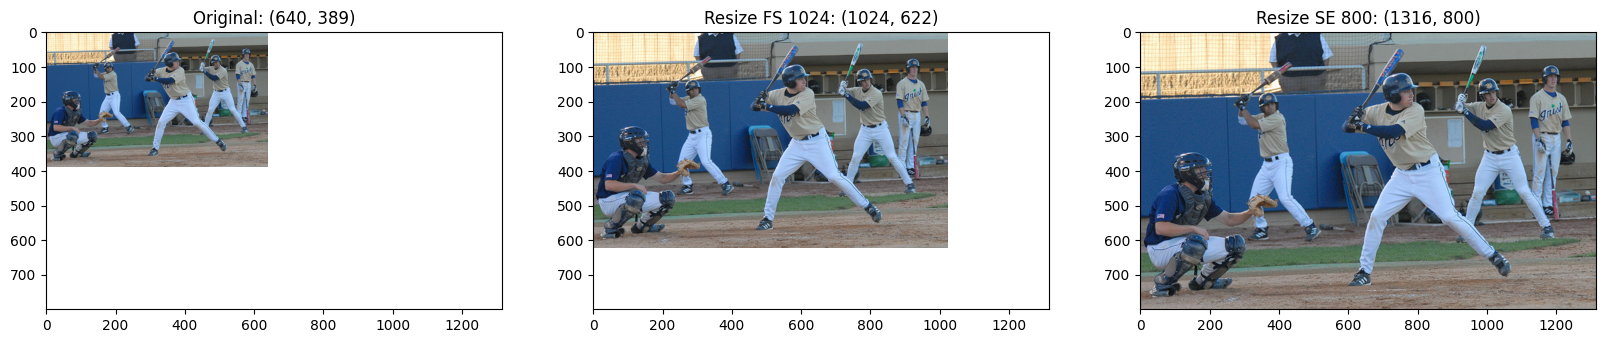

In [2]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

def resize_pil_img(img, target_size=1024, max_size=1024, shortes_edge=False):

    w, h = img.size

    if shortes_edge:
        scale_factor = target_size / min([w,h])
    else:
        scale_factor = target_size / max([w,h])

    new_w, new_h = int(w * scale_factor), int(h * scale_factor)

    assert new_w <= max_size, new_h <= max_size

    return img.resize(size=(new_w, new_h))

img = Image.open("./000000160864.jpg")
img_fs_1024 = resize_pil_img(img, target_size=1024, max_size=1024, shortes_edge=False)
img_se_800 =  resize_pil_img(img, target_size=800,  max_size=1333, shortes_edge=True)

fig = plt.figure(figsize=(20, 25))

ax = fig.add_subplot(1,3,1)
ax.set_title(f'Original: {img.size}')
ax.imshow(img)

ax = fig.add_subplot(1,3,2, sharex=ax, sharey=ax)
ax.set_title(f'Resize FS 1024: {img_fs_1024.size}')
ax.imshow(img_fs_1024)

ax = fig.add_subplot(1,3,3, sharex=ax, sharey=ax)
ax.set_title(f'Resize SE 800: {img_se_800.size}')
ax.imshow(img_se_800)


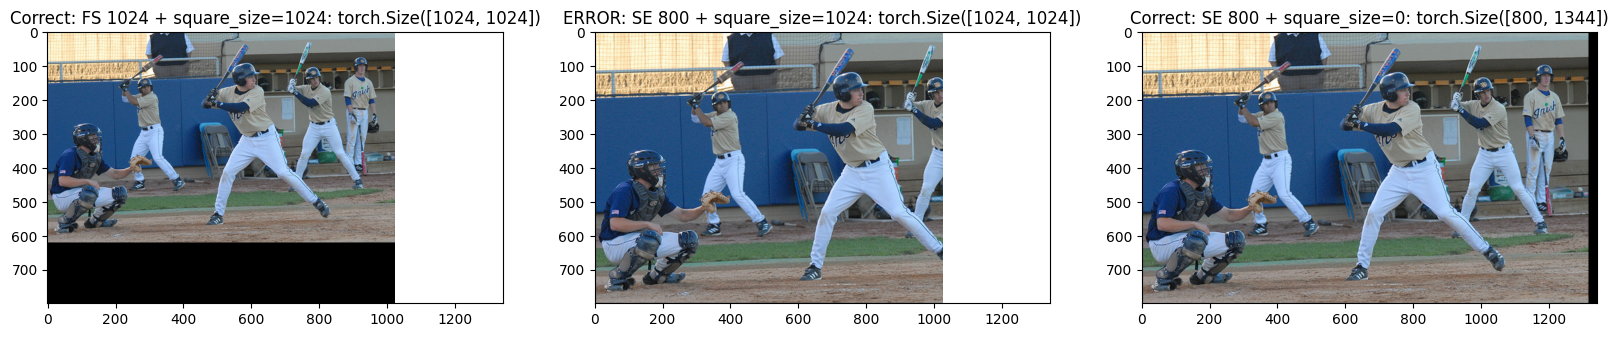

In [3]:
batch_img_fs_1024 = [torch.tensor(np.array(img_fs_1024)).permute(2,0,1)] # H,W,C -> C,H,W
batch_img_se_800  = [torch.tensor(np.array(img_se_800)).permute(2,0,1)]  # H,W,C -> C,H,W


# Now we fake the image pre-processing that runs in GeneralizedRCNN:
# https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/meta_arch/rcnn.py#L311
#
# images = ImageList.from_tensors(
#             images,
#             self.backbone.size_divisibility,
#             padding_constraints=self.backbone.padding_constraints,
#     )
#

# https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/backbone/vit.py#L467
size_divisibility =  32

# https://github.com/facebookresearch/detectron2/blob/main/configs/common/models/mask_rcnn_vitdet.py#L49
# https://github.com/facebookresearch/detectron2/blob/1e3e13bbf607b54f62205c4c33922521822fb298/detectron2/modeling/backbone/vit.py#L471
padding_constraints_1024 = { "size_divisiblity": size_divisibility, "square_size": 1024 }
padding_constraints_zero = { "size_divisiblity": size_divisibility, "square_size": 0 }

correct_fs_1024_list = ImageList.from_tensors(batch_img_fs_1024, size_divisibility, padding_constraints=padding_constraints_1024)
cropped_se_800_list = ImageList.from_tensors(batch_img_se_800, size_divisibility, padding_constraints=padding_constraints_1024)  # ERROR happens here!
correct_se_800_list = ImageList.from_tensors(batch_img_se_800, size_divisibility, padding_constraints=padding_constraints_zero)

# get images from ImageList and convert back for plt
correct_img_fs_1024 = correct_fs_1024_list.tensor[0].permute(1,2,0) # C,H,W -> H,W,C
cropped_img_se_800 = cropped_se_800_list.tensor[0].permute(1,2,0) # C,H,W -> H,W,C
correct_img_se_800 = correct_se_800_list.tensor[0].permute(1,2,0) # C,H,W -> H,W,C


fig = plt.figure(figsize=(20, 25))

ax = fig.add_subplot(1,3,1)
ax.set_title(f'Correct: FS 1024 + square_size=1024: {correct_img_fs_1024.shape[:2]}')
ax.imshow(correct_img_fs_1024)

ax = fig.add_subplot(1,3,2, sharex=ax, sharey=ax)
ax.set_title(f'ERROR: SE 800 + square_size=1024: {cropped_img_se_800.shape[:2]}')
ax.imshow(cropped_img_se_800)

ax = fig.add_subplot(1,3,3, sharex=ax, sharey=ax)
ax.set_title(f'Correct: SE 800 + square_size=0: {correct_img_se_800.shape[:2]}')
ax.imshow(correct_img_se_800)

### Reproduce correct and wrong Eval for MS-COCO and COCO-O

Now that you have seen the error (`square_pad=1024` in the nested ViTDet confing will actully crop larger images), we provide the correspondig evals as outlined in our paper!

In [4]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

In [5]:
def _coco_summarize(params, eval, ap=1, iouThr=None, areaRng='all', maxDets=100, verbose=False):
    """
    Modified version of _summarize, instead of self.params and self.eval we pass these as arguments
    See: https://github.com/cocodataset/cocoapi/blob/master/PythonAPI/pycocotools/cocoeval.py#L427

    :param params: cocoEval.params
    :param eval: cocoEval.eval
    :param verbose: only print if requested
    :return: the requested statistic
    """

    p = params
    iStr = ' {:<18} {} @[ IoU={:<9} | area={:>6s} | maxDets={:>3d} ] = {:0.3f}'
    titleStr = 'Average Precision' if ap == 1 else 'Average Recall'
    typeStr = '(AP)' if ap == 1 else '(AR)'
    iouStr = '{:0.2f}:{:0.2f}'.format(p.iouThrs[0], p.iouThrs[-1]) \
        if iouThr is None else '{:0.2f}'.format(iouThr)

    aind = [i for i, aRng in enumerate(p.areaRngLbl) if aRng == areaRng]
    mind = [i for i, mDet in enumerate(p.maxDets) if mDet == maxDets]
    if ap == 1:
        # dimension of precision: [TxRxKxAxM]
        s = eval['precision']
        # IoU
        if iouThr is not None:
            t = np.where(iouThr == p.iouThrs)[0]
            s = s[t]
        s = s[:, :, :, aind, mind]
    else:
        # dimension of recall: [TxKxAxM]
        s = eval['recall']
        if iouThr is not None:
            t = np.where(iouThr == p.iouThrs)[0]
            s = s[t]
        s = s[:, :, aind, mind]
    if len(s[s > -1]) == 0:
        mean_s = -1
    else:
        mean_s = np.mean(s[s > -1])
    if verbose:
        print("Return AP:")
        print(iStr.format(titleStr, typeStr, iouStr, areaRng, maxDets, mean_s))
    return mean_s


def run_coco_eval(ann_file, results_file, iou_type):

    assert iou_type in ['bbox']

    with open(results_file, 'r') as f:
        predictions = json.load(f)

    cocoGt = COCO(ann_file)
    cocoDt = cocoGt.loadRes(predictions)
    cocoEval = COCOeval(cocoGt, cocoDt, iou_type)

    cocoEval.evaluate()
    cocoEval.accumulate()
    cocoEval.summarize()

    params, eval = cocoEval.params, cocoEval.eval

    return _coco_summarize(params, eval, 1, verbose=True)


def run_coco_and_coco_o_eval(coco_anns, ood_anns, results_path, coco_results, ood_results):

    ms_coco_AP = run_coco_eval(coco_anns, results_path + coco_results, 'bbox')

    coco_o_APs = {}
    for ood_version in ["cartoon", "handmake", "painting", "sketch", "tattoo", "weather"]:
        print("EVAL:", ood_version)
        coco_o_APs[ood_version] = run_coco_eval(ood_anns[ood_version], results_path + ood_results[ood_version], 'bbox')

    return ms_coco_AP, coco_o_APs


In [6]:
coco_ann_file = "./annotations/coco/instances_val2017.json"
ood_ann_files = {
    "cartoon": "./annotations/ood_coco/cartoon/annotations/instances_val2017.json",
    "handmake":  "./annotations/ood_coco/handmake/annotations/instances_val2017.json",
    "painting":  "./annotations/ood_coco/painting/annotations/instances_val2017.json",
    "sketch":  "./annotations/ood_coco/sketch/annotations/instances_val2017.json",
    "tattoo":  "./annotations/ood_coco/tattoo/annotations/instances_val2017.json",
    "weather":  "./annotations/ood_coco/weather/annotations/instances_val2017.json"
}

coco_results_file = "ms-coco_results.bbox.json"
ood_results_files = {
    "cartoon": "coco-o_cartoon_results.bbox.json",
    "handmake":  "coco-o_handmake_results.bbox.json",
    "painting":  "coco-o_painting_results.bbox.json",
    "sketch":  "coco-o_sketch_results.bbox.json",
    "tattoo":  "coco-o_tattoo_results.bbox.json",
    "weather":  "coco-o_weather_results.bbox.json"
}

results_correct_1024 = "./vitdet_h/correct_1024/"
results_error_800 = "./vitdet_h/error_800/"
results_correct_800 = "./vitdet_h/correct_800/"

In [7]:
ms_coco_1024, coco_o_1024 = run_coco_and_coco_o_eval(coco_ann_file, ood_ann_files, results_correct_1024, coco_results_file, ood_results_files)
ms_coco_800_e, coco_800_e = run_coco_and_coco_o_eval(coco_ann_file, ood_ann_files, results_error_800, coco_results_file, ood_results_files)
ms_coco_800_c, coco_800_c = run_coco_and_coco_o_eval(coco_ann_file, ood_ann_files, results_correct_800, coco_results_file, ood_results_files)

loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.19s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.52s).
Accumulating evaluation results...
DONE (t=0.93s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.587
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.767
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.640
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.419
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.630
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.739
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.418
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.669
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [9]:
def computer_ER(coco_AP, coco_o_APs, verbose=True):

    if verbose:
        for k,v in coco_o_APs.items():
            print(f"COCO-O {k:<8}: {v*100:.2f}")
        print()

    coco_o_avg = np.mean(list(coco_o_APs.values()))
    coco_o_ER = coco_o_avg - 0.45 * coco_AP
    print(f"COCO-O Avg.{':':<5} {coco_o_avg*100:.2f}")
    print(f"MS-COCO{':':<9} {coco_AP*100:.2f}")
    print(f"COCO-O ER{':':<7} {coco_o_ER*100:.2f}")
    print("----------------------\n")

print("# Correct FS 1024:")
computer_ER(ms_coco_1024, coco_o_1024, verbose=False)

print("# Error SE 800")
computer_ER(ms_coco_800_e, coco_800_e, verbose=False)

print("# Correct SE 800")
computer_ER(ms_coco_800_c, coco_800_c, verbose=False)

print("# MISTAKE of Mao et al. 2023 (Correct FS 1024 ms-coco with error SE 800 coco-o)")
computer_ER(ms_coco_1024, coco_800_e, verbose=False)

# Correct FS 1024:
COCO-O Avg.:     36.31
MS-COCO:         58.71
COCO-O ER:       9.89
----------------------

# Error SE 800
COCO-O Avg.:     34.26
MS-COCO:         51.81
COCO-O ER:       10.94
----------------------

# Correct SE 800
COCO-O Avg.:     36.19
MS-COCO:         58.00
COCO-O ER:       10.09
----------------------

# MISTAKE of Mao et al. 2023 (Correct FS 1024 ms-coco with error SE 800 coco-o)
COCO-O Avg.:     34.26
MS-COCO:         58.71
COCO-O ER:       7.84
----------------------

